# Pelatihan SVM Berbasis FastText

Tahapan yang dilakukan meliputi:
1. **Membaca Dataset Final** 
2. **Feature Extraction (FastText)** 
3. **Train-Test Split** 
4. **Hyperparameter Tuning (GridSearchCV)** 
5. **Evaluasi Akademik** 
6. **Visualisasi Confusion Matrix**
7. **Ekspor Model Akhir**

In [37]:
import pandas as pd
import numpy as np
import fasttext
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.decomposition import PCA

from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import re

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Membaca Dataset Final
Memuat hasil data yang sudah disiapkan dan diseimbangkan (*undersampled*) pada modul Pra-Pemrosesan.

=== TAHAP 1: MEMUAT DATASET ===
[LOG] Total observasi siap latih: 1765 baris.


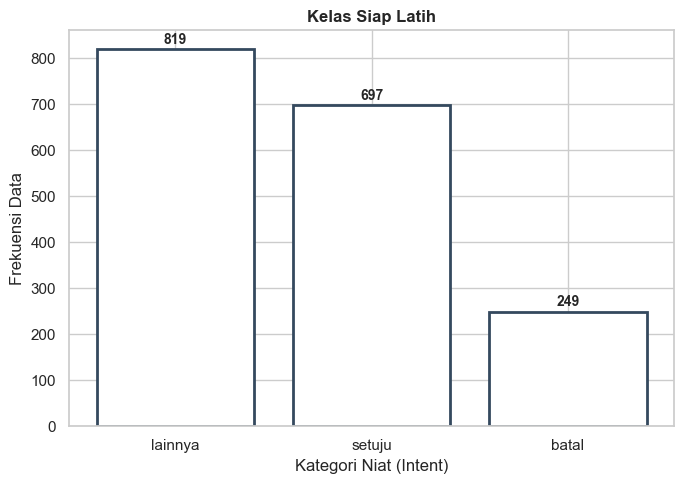

In [38]:
print("=== TAHAP 1: MEMUAT DATASET ===")
file_dataset = 'data/dataset_siap_latih_final.csv'
df = pd.read_csv(file_dataset)

# Memastikan tidak ada nilai kosong
df = df.dropna(subset=['clean_text', 'intent']).copy()

print(f"[LOG] Total observasi siap latih: {len(df)} baris.")

intent_counts = df['intent'].value_counts()
plt.figure(figsize=(7, 5))
bars = plt.bar(intent_counts.index, intent_counts.values, facecolor='white', edgecolor='#34495e', linewidth=2)
plt.title('Kelas Siap Latih', fontsize=12, fontweight='bold')
plt.xlabel('Kategori Niat (Intent)')
plt.ylabel('Frekuensi Data')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(int(bar.get_height())),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Ekstraksi Fitur (FastText Word Embeddings)
Mengubah teks menjadi ruang vektor matematis 300 dimensi. Untuk membuktikan secara visual bahwa representasi FastText bekerja dengan baik dalam memisahkan makna kata, kita akan mereduksi 300 dimensi tersebut menjadi 2 dimensi dengan algoritma PCA.

=== EKSTRAKSI FITUR FASTTEXT ===
[LOG] Memuat FastText pre-trained model (cc.id.300.bin)... 
[LOG] Ekstraksi vektor kalimat...
[LOG] Mereduksi 300 Dimensi FastText menjadi 2D untuk visualisasi...


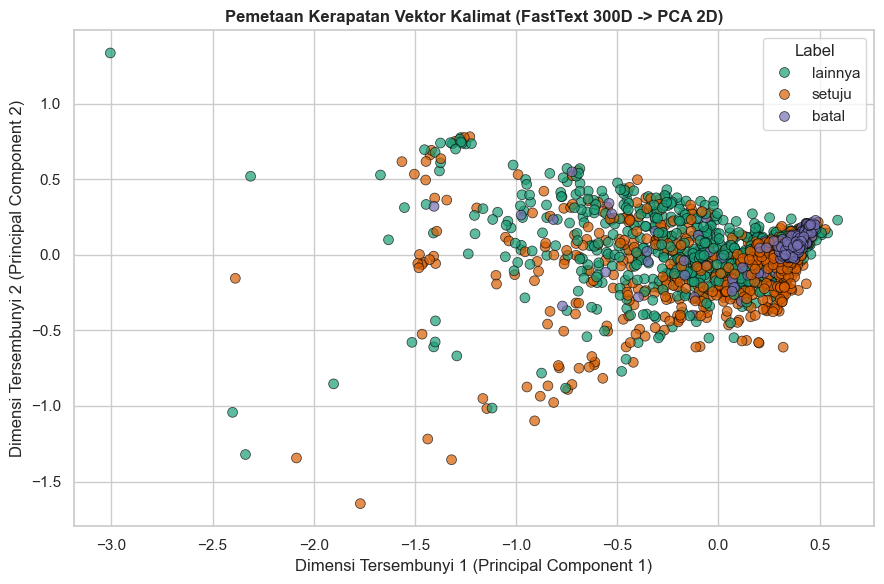

In [39]:
print("=== EKSTRAKSI FITUR FASTTEXT ===")

# Memuat model pra-latih (pre-trained model) FastText khusus bahasa Indonesia (cc.id.300.bin)
# Model ini merepresentasikan arsitektur Continuous Bag-of-Words (CBOW) dengan 300 dimensi fitur
print("[LOG] Memuat FastText pre-trained model (cc.id.300.bin)... ")
if not os.path.exists('models/cc.id.300.bin'):
    raise FileNotFoundError("File model cc.id.300.bin tidak ditemukan!")
    
ft_model = fasttext.load_model('models/cc.id.300.bin')
print("[LOG] Ekstraksi vektor kalimat...")

def get_sentence_vector(text, ft_model):
    """
    Fungsi ekstraksi fitur untuk mengonversi teks kalimat menjadi representasi ruang vektor kontinu (Continuous Vector Space).
    
    Pendekatan yang digunakan adalah komputasi rata-rata (Mean Pooling) dari seluruh word embeddings 
    yang menyusun suatu kalimat. Rata-rata vektor ini berfungsi untuk menangkap makna leksikal 
    dan semantik kalimat secara keseluruhan ke dalam matriks dimensi tetap (300D).
    """
    words = str(text).split()
    if not words:
        # Penanganan *Out-of-Vocabulary* (OOV) atau *null string*: Mengembalikan vektor nol
        return np.zeros(ft_model.get_dimension())
    
    # Ekstraksi vektor unigram/n-gram dari model FastText untuk setiap kata (token)
    word_vectors = [ft_model.get_word_vector(w) for w in words]
    
    # Agregasi vektor tingkat kata menjadi vektor tingkat dokumen/kalimat (Sentence Embedding)
    return np.mean(word_vectors, axis=0)

# Transformasi sekumpulan data latih teks menjadi matriks fitur prediktor (X)
X = np.array([get_sentence_vector(t, ft_model) for t in df['clean_text']])
# Ekstraksi variabel target (y) yang merepresentasikan kelas niat (intent)
y = df['intent'].values

# VISUALISASI 2: Reduksi Dimensionalitas dengan Principal Component Analysis (PCA)
# Melakukan proyeksi linier ortogonal untuk mereduksi 300 dimensi fitur asli (FastText) 
# menjadi 2 komponen utama (2D) demi memfasilitasi inspeksi visual persebaran kelas
print("[LOG] Mereduksi 300 Dimensi FastText menjadi 2D untuk visualisasi...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Pembuatan kerangka data (*Dataframe*) dua dimensi untuk pemetaan visual (Scatter Plot)
df_pca = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1], 'Label': y})

plt.figure(figsize=(9, 6))
# Visualisasi persebaran (*Scatterplot*) dari setiap titik data berdasarkan pelabelan kelas (*Ground Truth*)
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Label', palette='Dark2', s=50, edgecolor='black', alpha=0.7)
plt.title('Pemetaan Kerapatan Vektor Kalimat (FastText 300D -> PCA 2D)', fontsize=12, fontweight='bold')
plt.xlabel('Dimensi Tersembunyi 1 (Principal Component 1)')
plt.ylabel('Dimensi Tersembunyi 2 (Principal Component 2)')
plt.tight_layout()
plt.show()


## 3. Pembagian Data (*Train-Test Split*)
Membagi proporsi 80% data latih dan 20% data uji menggunakan teknik stratifikasi untuk menjaga komposisi kelas tetap proporsional.

=== PEMBAGIAN DATA (80:20) ===


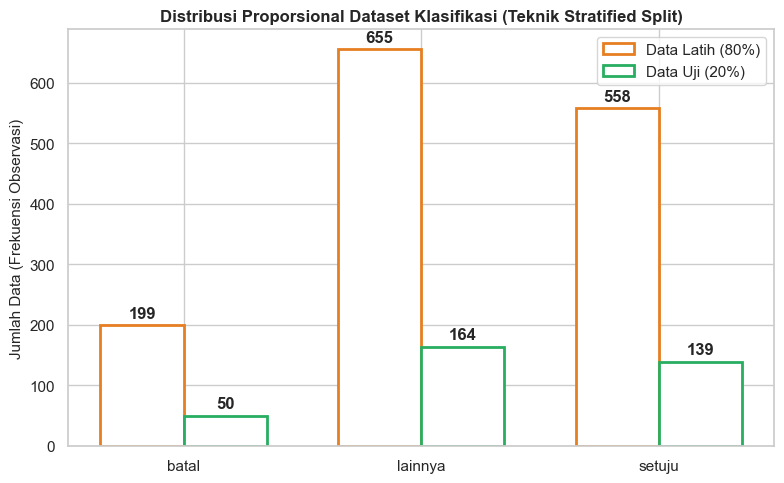

In [40]:
print("=== PEMBAGIAN DATA (80:20) ===")

# Pemisahan Matriks Fitur (X) dan Target Label (y) ke dalam himpunan Pelatihan (Train) dan Pengujian (Test)
# Proporsi pembagian yang digunakan adalah 80% untuk komputasi pelatihan model dan 20% untuk pengujian validasi
# Argumen 'stratify=y' ditambahkan sebagai teknik *Stratified Sampling* untuk memastikan bahwa 
# distribusi proporsional dari masing-masing kelas niat (intent) tetap seimbang dan representatif 
# di dalam set pelatihan maupun set pengujian (mencegah bias kelas minoritas).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Menyusun agregasi frekuensi data untuk keperluan visualisasi proporsi kelas
# np.unique menghitung kemunculan observasi dari tiap kelas ke dalam variabel array
labels, train_counts = np.unique(y_train, return_counts=True)
_, test_counts = np.unique(y_test, return_counts=True)

# Konfigurasi titik kordinat (X-axis) dan lebar batang visualisasi (Bar chart)
x_pos = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

# Plotting distribusi himpunan pelatihan (Data Latih) 
rects1 = ax.bar(x_pos - width/2, train_counts, width, label='Data Latih (80%)', facecolor='white', edgecolor='#e67e22', linewidth=2)
# Plotting distribusi himpunan pengujian (Data Uji) berdampingan dengan Data Latih
rects2 = ax.bar(x_pos + width/2, test_counts, width, label='Data Uji (20%)', facecolor='white', edgecolor='#27ae60', linewidth=2)

ax.set_ylabel('Jumlah Data (Frekuensi Observasi)', fontsize=11)
ax.set_title('Distribusi Proporsional Dataset Klasifikasi (Teknik Stratified Split)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    """
    Fungsi utilitas untuk melakukan anotasi nilai numerik eksak di atas setiap batang grafik.
    Memudahkan interpretasi komparatif antara frekuensi himpunan latih dan uji.
    """
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

# Mengeksekusi penambahan anotasi pada kedua grafik batang
autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()


## 4. Pelatihan Model & *Hyperparameter Tuning*
Mencari konfigurasi model SVM terbaik melalui *Cross Validation*.

=== GRIDSEARCH & TRAINING ===
[LOG] Memulai komputasi hyperparameter tuning (harap tunggu)...

[HASIL] Parameter Paling Optimal: {'C': 10, 'class_weight': 'balanced', 'kernel': 'rbf'}


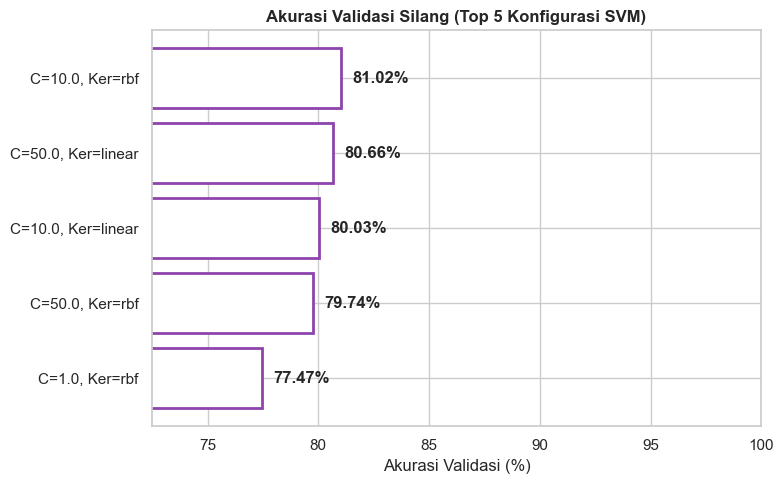

In [41]:
print("=== GRIDSEARCH & TRAINING ===")

# Definisikan ruang pencarian (Search Space) Hyperparameter untuk model Support Vector Machine (SVM)
param_grid = {
    # C (Regularization parameter): Mengontrol penalti (*trade-off*) antara kesalahan klasifikasi pada data latih 
    # terhadap maksimasi margin (batas keputusan). Nilai tinggi cenderung overfit, nilai rendah berpotensi underfit.
    'C': [0.1, 1, 10, 50],
    
    # Kernel: Fungsi matematis untuk memetakan input non-linear ke dalam dimensi yang lebih tinggi. 
    # Linier (Linear) memisahkan data dengan garis lurus, RBF (Radial Basis Function) menangani pola data yang lebih kompleks.
    'kernel': ['linear', 'rbf'],
    
    # Class_weight='balanced': Secara otomatis menyesuaikan pembobotan penalti secara berbanding terbalik 
    # dengan frekuensi kelas, ini adalah strategi jitu untuk menangani imbalanced dataset.
    'class_weight': ['balanced']
}

# Strategi Validasi Silang (Cross-Validation Strategy)
# Menggunakan Stratified 5-Fold untuk membagi himpunan latih menjadi 5 bagian lipatan dengan tetap
# mempertahankan rasio proporsi asli (imbalance ratio) dari masing-masing kelas target.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Menginisialisasi objek GridSearchCV untuk melakukan pencarian iteratif komprehensif (Exhaustive Search)
# Argumen probability=True ditambahkan untuk mengekstraksi tingkat keyakinan (confidence score) dari setiap prediksi kelas.
# Argumen n_jobs=-1 memerintahkan prosesor menggunakan seluruh inti (cores) CPU untuk komputasi paralel.
grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1
)

print("[LOG] Memulai komputasi hyperparameter tuning (harap tunggu)...")
# Mengeksekusi pelatihan model ke seluruh kombinasi parameter (Grid)
grid_search.fit(X_train, y_train)

# Mengekstraksi arsitektur model dengan kombinasi parameter terbaik (Best Estimator)
best_svm_clf = grid_search.best_estimator_

print(f"\n[HASIL] Parameter Paling Optimal: {grid_search.best_params_}")

# Kinerja 5 Kombinasi Parameter Teratas
# Membentuk struktur Dataframe dari riwayat evaluasi silang (Cross-Validation Results)
results = pd.DataFrame(grid_search.cv_results_)

# Mengurutkan performa metrik akurasi pengujian rata-rata secara menurun (Descending) dan mengambil 5 tertinggi
top_5_results = results.sort_values(by='mean_test_score', ascending=False).head(5)

# Merangkai string kombinasi nilai C dan Kernel untuk label sumbu Y pada visualisasi
model_configs = top_5_results.apply(lambda x: f"C={x['param_C']}, Ker={x['param_kernel']}", axis=1)
# Mengonversi skala akurasi validasi menjadi rentang persentase (0-100%)
scores = top_5_results['mean_test_score'] * 100

plt.figure(figsize=(8, 5))
# Plotting horizontal bar chart (grafik batang horizontal) untuk evaluasi parameter
bars = plt.barh(model_configs[::-1], scores[::-1], facecolor='white', edgecolor='#8e44ad', linewidth=2)
plt.title('Akurasi Validasi Silang (Top 5 Konfigurasi SVM)', fontsize=12, fontweight='bold')
plt.xlabel('Akurasi Validasi (%)')
plt.xlim(min(scores)-5, 100)

for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.2f}%",
             va='center', fontweight='bold')
plt.tight_layout()
plt.show()


## Evaluasi Kinerja Model (*Testing*)
Menguji *Best Estimator* secara langsung pada himpunan Data Uji.

=== EVALUASI KINERJA ===
--- Laporan Matriks Klasifikasi ---
              precision    recall  f1-score   support

       batal       0.94      0.94      0.94        50
     lainnya       0.84      0.89      0.87       164
      setuju       0.88      0.82      0.85       139

    accuracy                           0.87       353
   macro avg       0.89      0.88      0.88       353
weighted avg       0.87      0.87      0.87       353



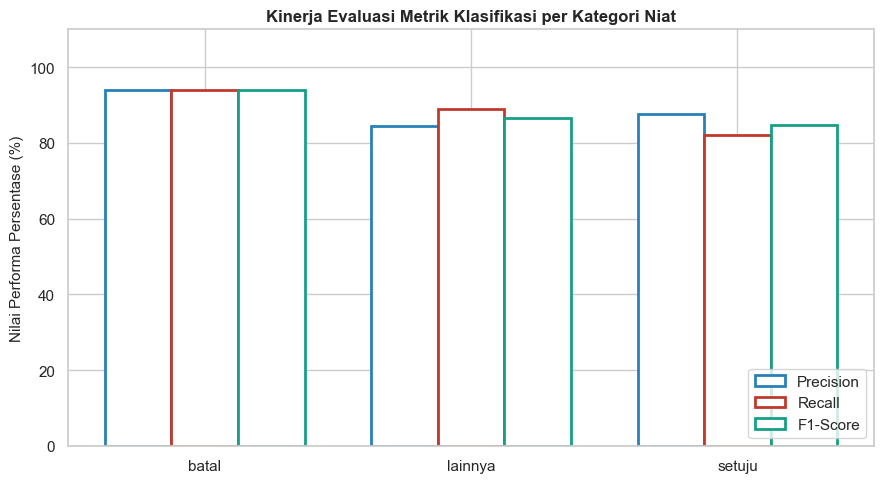

In [42]:
print("=== EVALUASI KINERJA ===")

# Melakukan prediksi terhadap himpunan data uji (X_test) menggunakan model SVM terbaik hasil komputasi GridSearchCV
y_pred = best_svm_clf.predict(X_test)

print("--- Laporan Matriks Klasifikasi ---")
# Menghasilkan kalkulasi matriks performa komprehensif (Precision, Recall, F1-Score, dan Support)
# untuk mengevaluasi objektivitas hasil prediksi terhadap data asli (y_test).
print(classification_report(y_test, y_pred))

# Mengekstraksi nilai dari metrik performa masing-masing kelas target secara parsial
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred, labels=labels)

# Konfigurasi parameter skala titik ordinat dan ukuran lebar batang diagram
x_pos = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

# Plotting grafik batang (Grouped Bar Chart) untuk membandingkan ketiga metrik secara sejajar per kelas
# Precision: Mengukur tingkat ketepatan tebakan positif model (Meminimalisir False Positives)
rects1 = ax.bar(x_pos - width, precision * 100, width, label='Precision', facecolor='white', edgecolor='#2980b9', linewidth=2)
# Recall (Sensitivitas): Mengukur kemampuan model menangkap seluruh data positif sesungguhnya (Meminimalisir False Negatives)
rects2 = ax.bar(x_pos, recall * 100, width, label='Recall', facecolor='white', edgecolor='#c0392b', linewidth=2)
# F1-Score: Nilai rata-rata harmonik (Harmonic Mean) antara Precision dan Recall, parameter paling akurat untuk dataset Imbalanced
rects3 = ax.bar(x_pos + width, fscore * 100, width, label='F1-Score', facecolor='white', edgecolor='#16a085', linewidth=2)

# Konfigurasi label sumbu visualisasi
ax.set_ylabel('Nilai Performa Persentase (%)', fontsize=11)
ax.set_title('Kinerja Evaluasi Metrik Klasifikasi per Kategori Niat', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
# Mengatur batas maksimal sumbu Y agar margin visual terlihat rapi (0% hingga 110%)
ax.set_ylim(0, 110)
ax.legend(loc='lower right')

fig.tight_layout()
plt.show()


## Visualisasi *Confusion Matrix*
Menampilkan kepadatan prediksi di area diagonal (yang menandakan prediksi tepat) berbalut desain palet biru monokromatik.

=== CONFUSION MATRIX ===


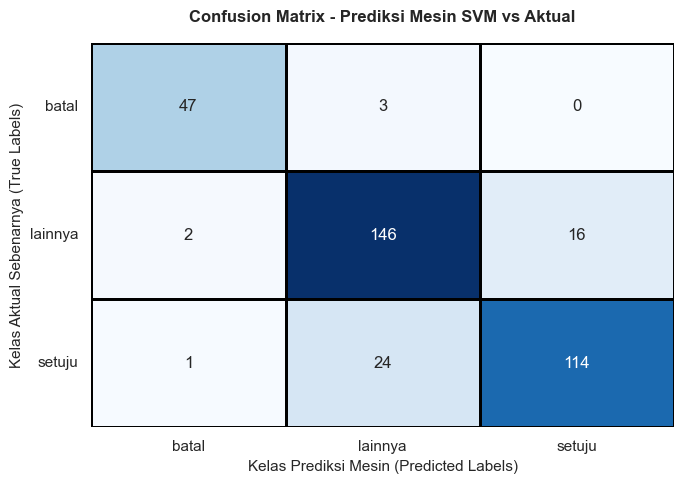

In [43]:
print("=== CONFUSION MATRIX ===")

# Menghitung matriks kebingungan (Confusion Matrix) untuk mengevaluasi kesalahan klasifikasi (Classification Error)
# Matriks ini menghitung frekuensi distribusi antara label Aktual (Sumbu Y) dengan label Prediksi (Sumbu X)
# Kombinasi ini akan menghasilkan nilai True Positives (TP), True Negatives (TN), False Positives (FP), dan False Negatives (FN)
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))

# Visualisasi matriks kebingungan ke dalam bentuk Peta Panas (Heatmap)
# Parameter annot=True: Menampilkan nilai eksak integer (fmt='d') frekuensi tebakan langsung ke dalam kotak matriks
# Parameter cmap='Blues': Memberikan gradasi warna; semakin pekat/gelap warnanya, semakin tinggi frekuensi tebakan di sel tersebut
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, 
            cbar=False, linewidths=1, linecolor='black')

plt.title('Confusion Matrix - Prediksi Mesin SVM vs Aktual', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Kelas Prediksi Mesin (Predicted Labels)', fontsize=11)
plt.ylabel('Kelas Aktual Sebenarnya (True Labels)', fontsize=11)

# Mengatur kemiringan teks label sumbu Y menjadi horizontal (0 derajat) agar mudah dibaca
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Validasi Silang (*K-Fold Cross Validation*)
Untuk membuktikan bahwa akurasi model tidak terjadi karena faktor kebetulan dalam pembagian data latih dan uji, kita melakukan uji validasi silang (Stratified 5-Fold) ke seluruh matriks fitur.

=== K-FOLD CROSS VALIDATION ===
Skor Akurasi tiap Lipatan (Fold): [0.81978799 0.80565371 0.79432624 0.81205674 0.82624113]
Rata-rata Akurasi Validasi Silang: 0.8116 (+/- 0.0222)


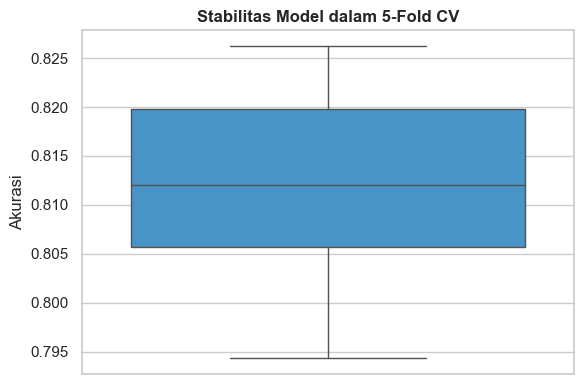

In [44]:
print("=== K-FOLD CROSS VALIDATION ===")
# Melakukan 5-Fold Cross Validation menggunakan model terbaik
cv_scores = cross_val_score(best_svm_clf, X_train, y_train, cv=5, scoring='accuracy')

print(f"Skor Akurasi tiap Lipatan (Fold): {cv_scores}")
print(f"Rata-rata Akurasi Validasi Silang: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Visualisasi Boxplot untuk melihat sebaran akurasi
plt.figure(figsize=(6, 4))
sns.boxplot(y=cv_scores, color='#3498db')
plt.title('Stabilitas Model dalam 5-Fold CV', fontsize=12, fontweight='bold')
plt.ylabel('Akurasi')
plt.tight_layout()
plt.show()

## Kurva Pembelajaran (*Learning Curve*)
Visualisasi ini sangat krusial dalam skripsi Machine Learning untuk membuktikan bahwa model tidak mengalami *Overfitting* maupun *Underfitting*.

=== LEARNING CURVE ===


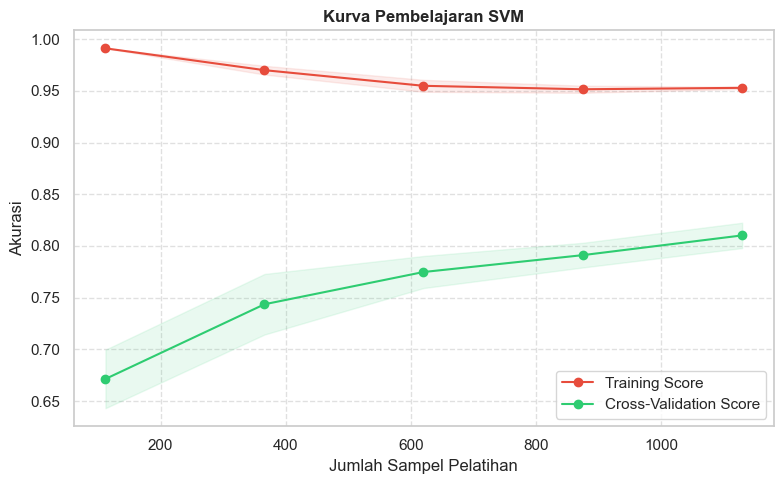

In [45]:
print("=== LEARNING CURVE ===")
train_sizes, train_scores, test_scores = learning_curve(
    best_svm_clf, X_train, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="#e74c3c", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="#2ecc71", label="Cross-Validation Score")

plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="#e74c3c")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="#2ecc71")

plt.title('Kurva Pembelajaran SVM', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Sampel Pelatihan')
plt.ylabel('Akurasi')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Kurva ROC-AUC Multi-Kelas
Mengevaluasi sensitivitas model dalam membedakan masing-masing kelas (Setuju, Batal, Lainnya) dengan menggunakan pendekatan *One-vs-Rest* (OvR).

=== ROC-AUC CURVE ===


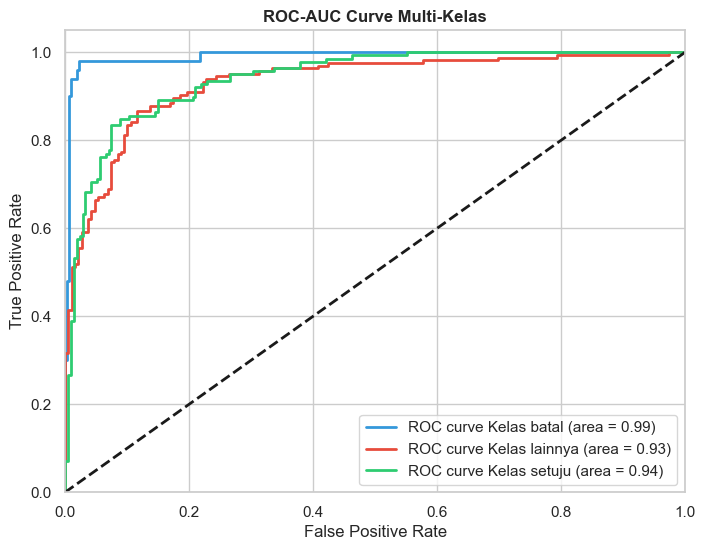

In [46]:
print("=== ROC-AUC CURVE ===")
# Mengubah label teks menjadi bentuk biner (One-vs-Rest)
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Memprediksi probabilitas tiap kelas
y_score = best_svm_clf.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = ['#3498db', '#e74c3c', '#2ecc71']
plt.figure(figsize=(8, 6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve Kelas {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Multi-Kelas', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

## Simulasi Pengujian Langsung

In [47]:
print("=== TESTING ===")

# Fungsi Normalisasi Teks Mandiri
def normalize_live_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def test_model(input_text):
    # 1. Normalisasi
    clean_text = normalize_live_text(input_text)
    
    # 2. Ekstraksi Fitur FastText
    vector = ft_model.get_sentence_vector(clean_text).reshape(1, -1)
    
    # 3. Prediksi dan Probabilitas
    prediction = best_svm_clf.predict(vector)[0]
    probabilities = best_svm_clf.predict_proba(vector)[0]
    
    print(f"Teks Asli      : '{input_text}'")
    print(f"Teks Bersih    : '{clean_text}'")
    print(f"\n> PREDIKSI NIAT: **{prediction.upper()}**")
    
    print("\n> Probabilitas Tiap Kelas:")
    for cls, prob in zip(best_svm_clf.classes_, probabilities):
        print(f"  - {cls}: {prob*100:.2f}%")

kalimat_baru = "Aduh bang mahal amat, ndak jadi lah"

print("\n-- MEMULAI UJI COBA --\n")
test_model(kalimat_baru)


=== TESTING ===

-- MEMULAI UJI COBA --

Teks Asli      : 'Aduh bang mahal amat, ndak jadi lah'
Teks Bersih    : 'aduh bang mahal amat ndak jadi lah'

> PREDIKSI NIAT: **BATAL**

> Probabilitas Tiap Kelas:
  - batal: 61.12%
  - lainnya: 30.49%
  - setuju: 8.40%


## Ekspor Model
Menyimpan matriks kecerdasan buatan dalam format biner yang padat.

In [48]:
print("=== TAHAP 7: EKSPOR MODEL FINAL ===")
model_filename = 'svm_model_final.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_svm_clf, file)
print(f"✅ BERHASIL: Model klasifikasi cerdas telah disimpan dengan nama '{model_filename}'")

=== TAHAP 7: EKSPOR MODEL FINAL ===
✅ BERHASIL: Model klasifikasi cerdas telah disimpan dengan nama 'svm_model_final.pkl'
